# Image Processing and Machine Vision - EN3160

#### R K T Dissanayake
#### 230164K

# Intensity Transformations and Neighborhood Filtering

Importing necessary packages

In [84]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d
from skimage.metrics import structural_similarity as ssim

### Implement the intensity transformation depicted in Fig.1 a on the image shown in Fig.1 b by writing a function intensity_transform(im,breakpoints)

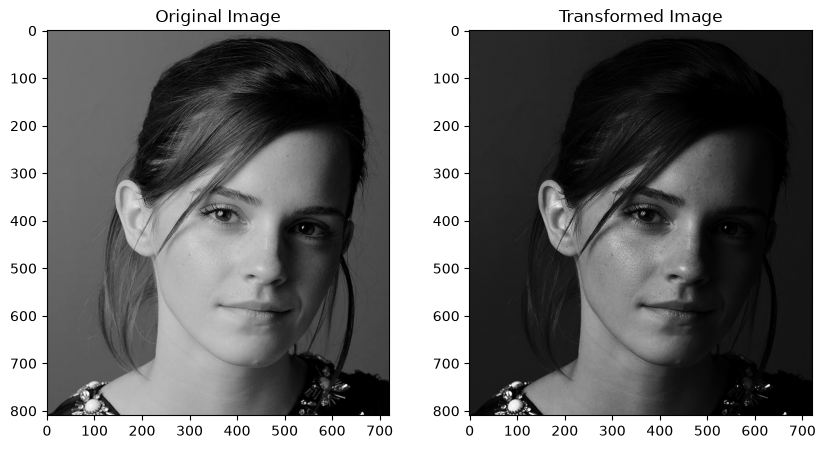

In [85]:
def intensity_transformation(im, breakpoints):
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        mask = (im >= x1) & (im < x2)
        im[mask] = (im[mask] * slope + intercept)%256

# Load an image
img = cv.imread(r"D:\Sem 5\IP and CV\images\images\emma.jpeg", cv.IMREAD_GRAYSCALE)

breakpoints = [(0,0), (100, 30), (150, 80), (200, 170), (220, 230),(255, 255)]
transformed_img = img.copy()
intensity_transformation(transformed_img, breakpoints)

# Display the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(transformed_img, cmap='gray')
plt.title('Transformed Image')
plt.show()

### Applying similar operation  to accentuate white matter

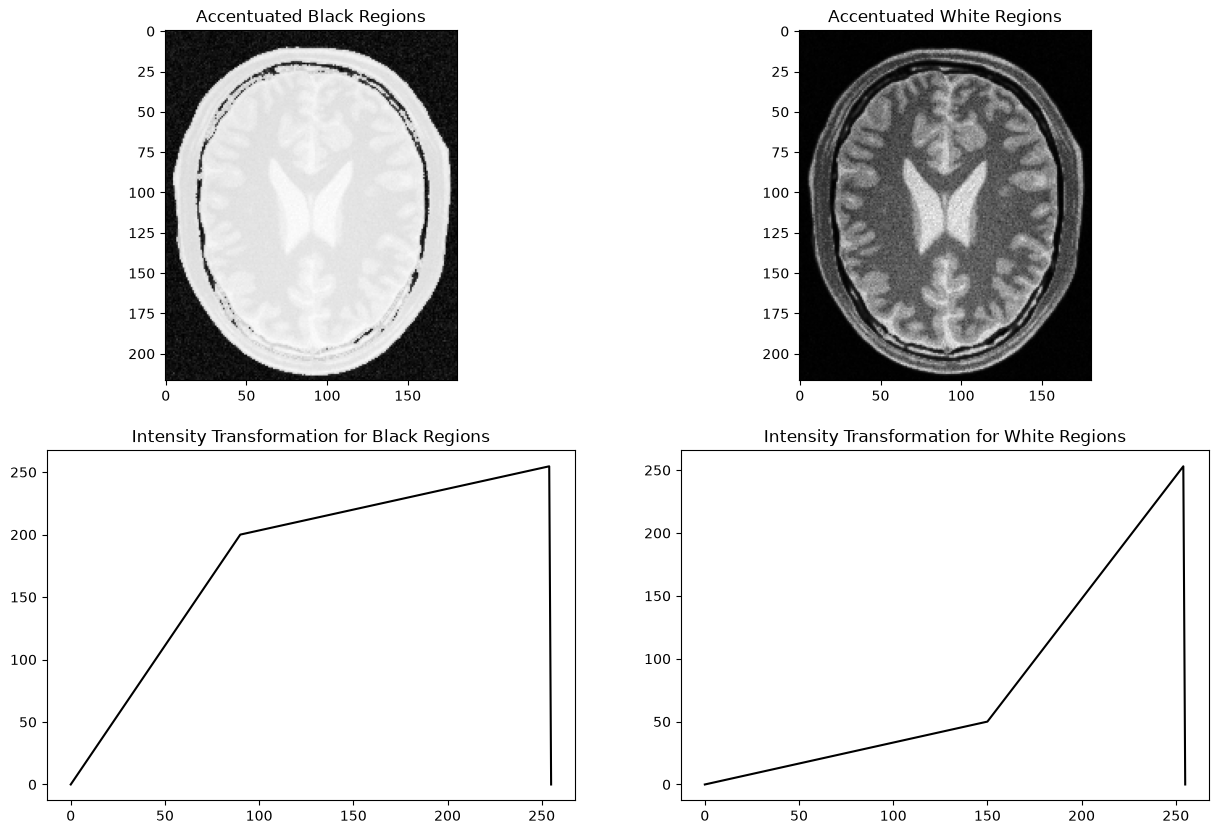

In [86]:
brain = cv.imread(r"D:\Sem 5\IP and CV\images\images\brain.png", cv.IMREAD_GRAYSCALE)

def intensity_transformation_plot(breakpoints):
    y_transformed = np.zeros(256)
    x = np.arange(256)
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        mask = (x >= x1) & (x < x2)
        y_transformed[mask] = (x[mask] * slope + intercept) % 256
    return y_transformed
  

# define breakout points to accentuate white regions
black_breakpoints = [(0, 0), (90, 200), (255, 255)]
white_breakpoints = [(0, 0), (150, 50), (255, 255)]

white_transformed_img = brain.copy()
intensity_transformation(white_transformed_img, white_breakpoints)
black_transformed_img = brain.copy()
intensity_transformation(black_transformed_img, black_breakpoints)

# Intensity transformation to accentuate white regions and black regions
x = np.arange(256)
y_white = intensity_transformation_plot(white_breakpoints)
y_black = intensity_transformation_plot(black_breakpoints)

# Display the image
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(black_transformed_img, cmap='gray')
plt.title('Accentuated Black Regions')

plt.subplot(2, 2, 2)
plt.imshow(white_transformed_img, cmap='gray')
plt.title('Accentuated White Regions')

plt.subplot(2, 2, 3)
plt.plot(x, y_black, color='black')
plt.title('Intensity Transformation for Black Regions')

plt.subplot(2, 2, 4)
plt.plot(x, y_white, color='black')
plt.title('Intensity Transformation for White Regions')

plt.show()


The accentuate white matter small range of high intensity pixels are mapped to a large range of output pixels. To accetuate black matter small range of low intensity pixels of the input image is maped to large range of pixels in the output.

## Gamma Correction

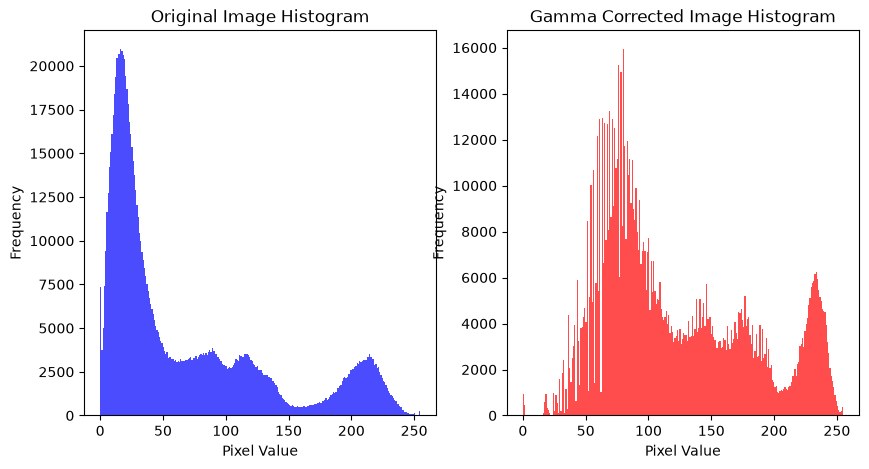

In [87]:
# load image girl
girl = cv.imread(r"D:\Sem 5\IP and CV\images\images\girl.jpeg", cv.IMREAD_COLOR)

# convert to YUV color space
girl_yuv = cv.cvtColor(girl, cv.COLOR_BGR2YUV)

# applying gamma correction to L plane
girl_yuv[:,:,0] = np.power(girl_yuv[:,:,0]/255.0, 0.469) * 255.0

# convert back to BGR color space
girl_gamma_corrected = cv.cvtColor(girl_yuv, cv.COLOR_YUV2BGR)

# Display histogram of original and gamma corrected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(girl.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Original Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(girl_gamma_corrected.ravel(), bins=256, color='red', alpha=0.7)
plt.title('Gamma Corrected Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()


The gamma value is 0.469

### Increasing vibrance of a photo

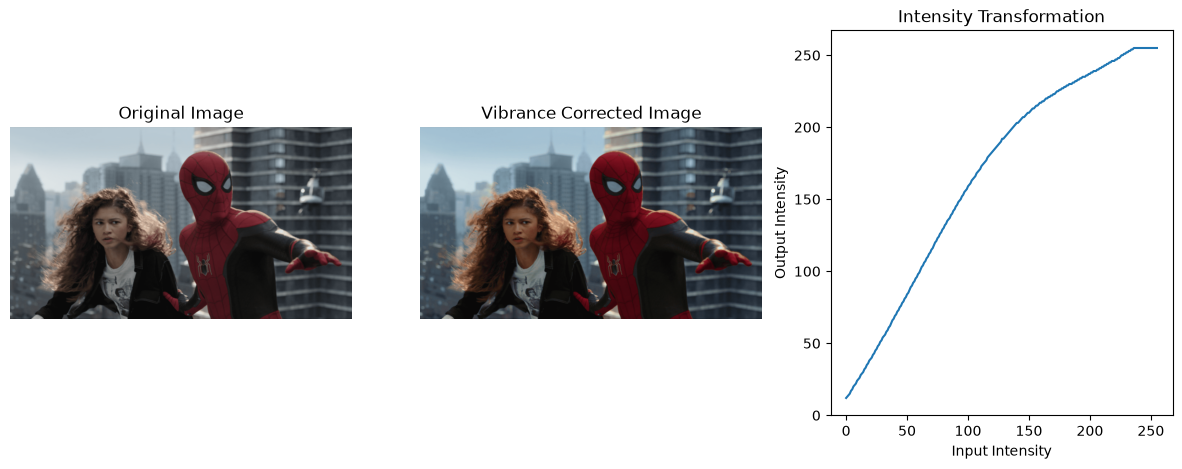

In [88]:
# load an image
peter = cv.imread(r"D:\Sem 5\IP and CV\images\images\peter.png", cv.IMREAD_COLOR)

# split image into hue, saturation, and value planes
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)

h, s, v = cv.split(peter_hsv)

# perameters
sigma = 70
vibrance_factor = 0.5

# Apply transformation
s_float = s.astype(np.float32)

s_new = s_float + vibrance_factor * 128 * np.exp(-((s_float - 128) ** 2) / (2 * sigma ** 2))

s_new = np.clip(s_new, 0, 255).astype(np.uint8)

# Recombine HSV
hsv_enhanced = cv.merge([h, s_new, v])

# Convert back to BGR
enhanced = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2BGR)

# Intensity transformation
x = np.arange(256, dtype=np.float32)
y = x + vibrance_factor * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
y = np.clip(y, 0, 255).astype(np.uint8)

# Display the image

# Original image
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(peter, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# Vibrance corrected image
plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
plt.title("Vibrance Corrected Image")
plt.axis("off")

# Intensity transformation
plt.subplot(1, 3, 3)
plt.plot(x, y)
plt.title("Intensity Transformation")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")

plt.show()


Value of a is 0.5

###  Write a function of your own to carry out histogram equalization on the image shown in Fig. 5. Show the histograms before and after equalization.

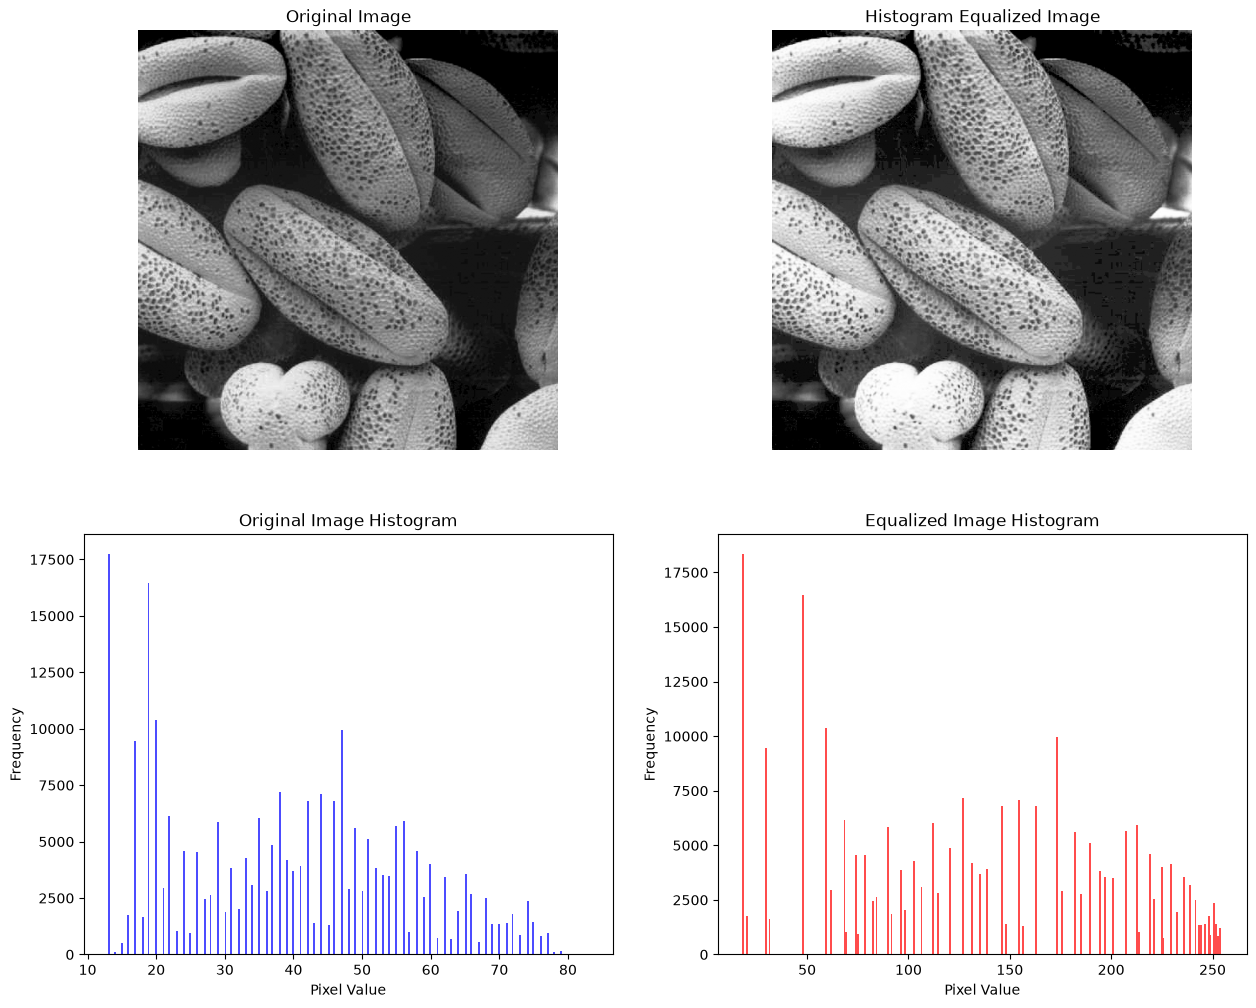

In [89]:
# load an image
bean = cv.imread(r"D:\Sem 5\IP and CV\images\images\beans.png", cv.IMREAD_GRAYSCALE)

# Histogram equalization function
def histogram_equalization(im):
    M, N = im.shape
    L = 256
    t = np.zeros(256, dtype=np.uint8)
    hist, bins = np.histogram(im.ravel(), 256, [0, 256])
    cdf = hist.cumsum()
    t = np.array([(L-1)/(M*N)*cdf[i] for i in range(256)], dtype=np.uint8)
    g = t[im]

    return g

# Apply histogram equalization
equalized_bean = histogram_equalization(bean)

# Display the images and histograms
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
plt.imshow(bean, cmap='gray')   
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized_bean, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(bean.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Original Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
plt.hist(equalized_bean.ravel(), bins=256, color='red', alpha=0.7)
plt.title('Equalized Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.show()


### apply histogram equalization only to the foreground of an image to produce an image with a histogram equalized foreground

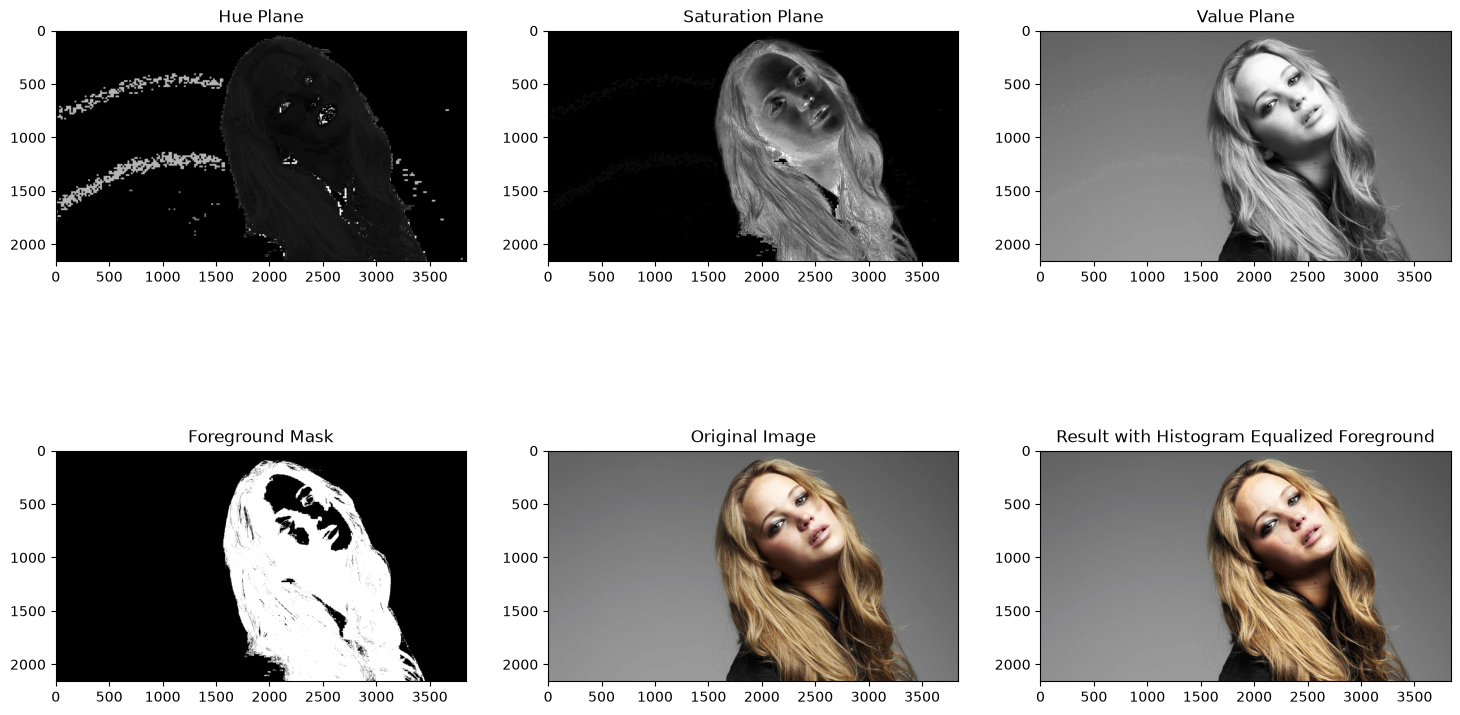

In [90]:
# load an image
jennifer = cv.imread(r"D:\Sem 5\IP and CV\images\images\jennifer.jpeg", cv.IMREAD_COLOR)

# split image into hue, saturation, and value planes

hsv = cv.cvtColor(jennifer, cv.COLOR_BGR2HSV)

h, s, v = cv.split(hsv)

# Select the appropriate plane to threshold in extracting the foreground mask
thresholded_sat = cv.threshold(s, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1]

# obtain the foreground only using cv.bitwise_and and compute the histogram
foreground = cv.bitwise_and(jennifer, jennifer, mask=thresholded_sat)

# Computing histogram equalization on the on the value plane
fg_v = cv.bitwise_and(v, v, mask=thresholded_sat)

histogram = cv.calcHist([v], [0], thresholded_sat, [256], [0, 256]).flatten()

# cummulative histogram
cdf = np.cumsum(histogram)

# histogram equalize foreground using the formula in slides
num_fg_pixels = cv.countNonZero(thresholded_sat)
L = 256
t = np.round((L - 1) * cdf / num_fg_pixels).astype(np.uint8)

equalized_v = v.copy()
equalized_v[thresholded_sat == 255] = t[v[thresholded_sat == 255]]

# Rebuild HSV with the equalized V channel
equalized_hsv = cv.merge([h, s, equalized_v])
equalized_bgr = cv.cvtColor(equalized_hsv, cv.COLOR_HSV2BGR)

# The foreground part of equalized color image
equalized_foreground = cv.bitwise_and(equalized_bgr, equalized_bgr, mask=thresholded_sat)

# Extract background and add to the equalized foreground
background = cv.bitwise_and(jennifer, jennifer, mask=cv.bitwise_not(thresholded_sat))

result = cv.add(background, equalized_foreground)

# Display the hue, saturation, and value planes, mask, original image, and the result with histogram equalized foreground
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(h, cmap='gray')
plt.title("Hue Plane")

plt.subplot(2, 3, 2)
plt.imshow(s, cmap='gray')
plt.title("Saturation Plane")

plt.subplot(2, 3, 3)
plt.imshow(v, cmap='gray')
plt.title("Value Plane")

plt.subplot(2, 3, 4)
plt.imshow(thresholded_sat, cmap='gray')
plt.title("Foreground Mask")

plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(jennifer, cv.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(2, 3, 6)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title("Result with Histogram Equalized Foreground")

plt.show()

The saturation plane was selected because saturation plane showed the best separation between the subject and the background. Otsu was used because it picks the threshold automatically. Histogram was computed over foreground pixels only, not over the full image (which would cause a huge spike at 0 from all the masked-out background pixels). 

###   Filtering with the Sobel operator

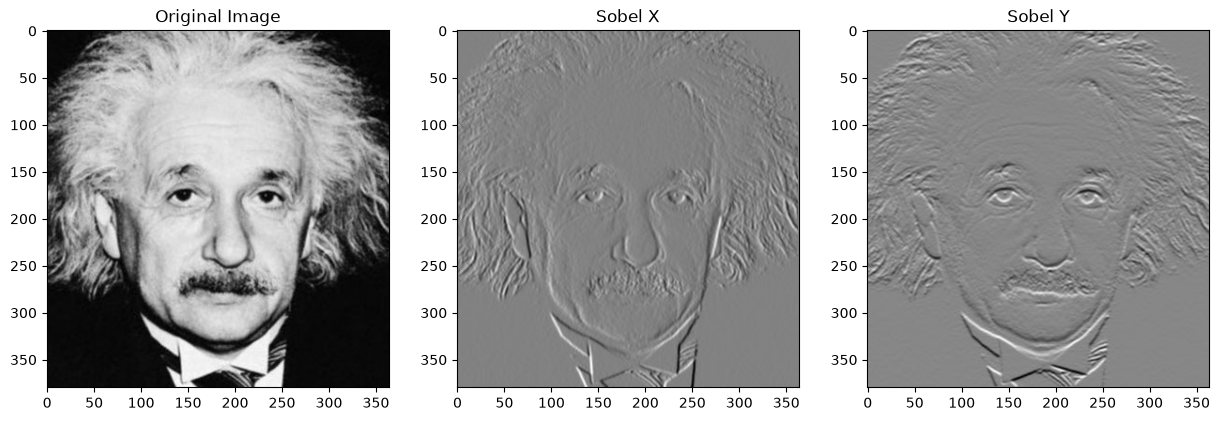

In [91]:
# load image
albert = cv.imread(r"D:\Sem 5\IP and CV\images\images\albert.png", cv.IMREAD_GRAYSCALE)

sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

albert_sobel_x = cv.filter2D(albert, cv.CV_64F, sobel_x)
albert_sobel_y = cv.filter2D(albert, cv.CV_64F, sobel_y)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(albert, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(albert_sobel_x, cmap='gray')
plt.title("Sobel X")

plt.subplot(1, 3, 3)
plt.imshow(albert_sobel_y, cmap='gray')
plt.title("Sobel Y")

plt.show()


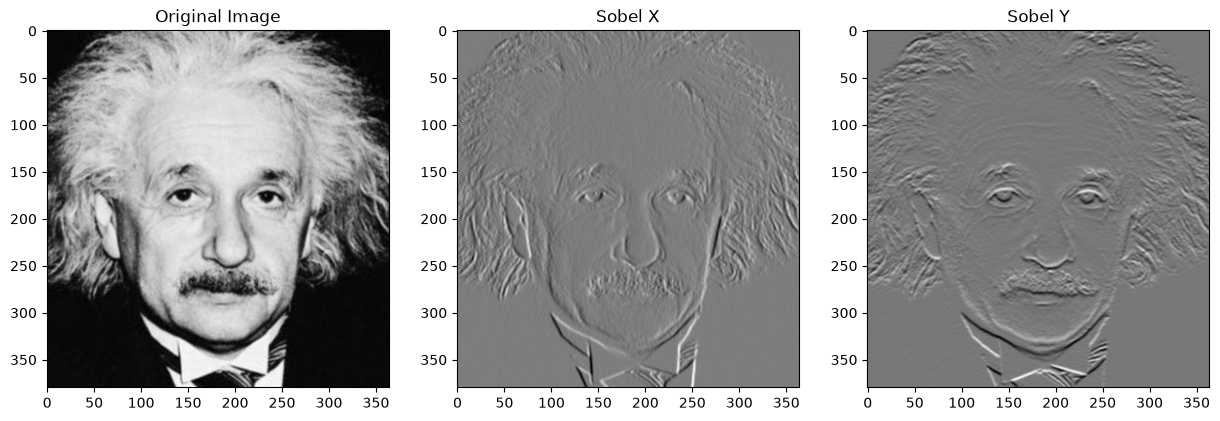

In [92]:
albert_f = albert.astype(np.float32)

# Sobel filtering using two 1D filters
x = np.array([1, 2, 1], dtype=np.float32)
y = np.array([-1, 0, 1], dtype=np.float32)

# Sobel X
gx = convolve1d(albert_f, y, axis=1, mode='reflect')
gx = convolve1d(gx, x, axis=0, mode='reflect')

# Sobel Y
gy = convolve1d(albert_f, y, axis=0, mode='reflect')
gy = convolve1d(gy, x, axis=1, mode='reflect')


# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(albert, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(gx, cmap='gray')
plt.title("Sobel X")

plt.subplot(1, 3, 3)
plt.imshow(gy, cmap='gray')
plt.title("Sobel Y")


plt.show()


The Sobel X filter detects vertical edges because it computes the derivative of intensity along the x-direction, which produces a strong response wherever brightness changes sharply as we move horizontally (when crossing a vertical line or edge); the accompanying smoothing along the y-direction to reduce noise along that edge. Similarly Sobel Y detects horizontal edges because it computes the derivative along the y-direction, responding strongly where brightness changes sharply as we move vertically, with smoothing applied along x.

### Program to zoom images by a given factor s ∈ (0,10]. You must use a function to zoom the image, which can handle nearest-neighbor,and bilinear interpolation.

In [93]:
# Function to zoom image
def zoom_image(image, zoom_factor, method):
    if method == 'nearest':
        # Nearest neighbor interpolation
        zoomed_image = cv.resize(image, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv.INTER_NEAREST)
    elif method == 'bilinear':
        # Bilinear interpolation
        zoomed_image = cv.resize(image, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv.INTER_LINEAR)
    
    return zoomed_image

### Using grabcut for segmentation

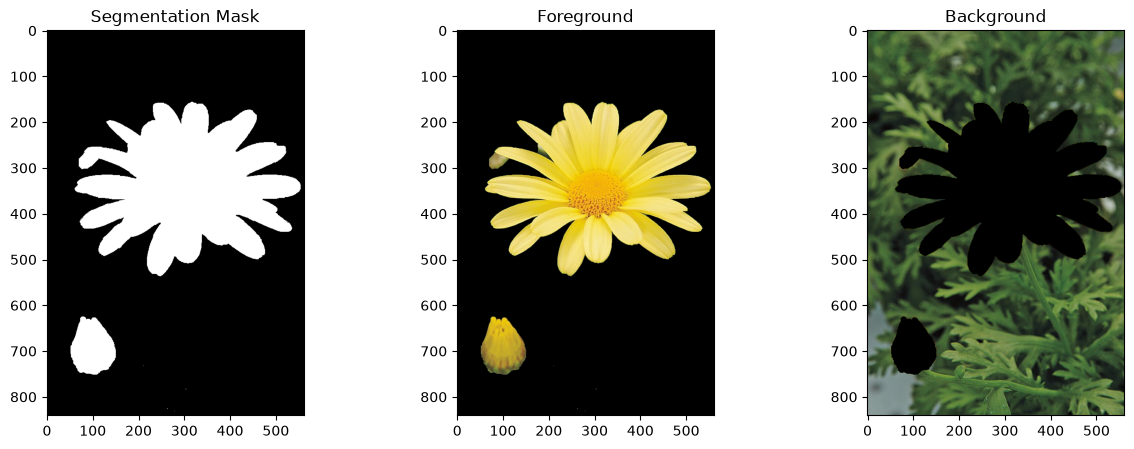

In [94]:
# load image
flower = cv.imread(r"D:\Sem 5\IP and CV\images\images\flower.jpeg", cv.IMREAD_COLOR)

# Using grabcut to get the segmentation mask of the flower
mask = np.zeros(flower.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define a rectangle around the flower
rect = (50, 50, flower.shape[1]-50, flower.shape[0]-50)

cv.grabCut(flower, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

# Create binary mask: 1 for foreground, 0 for background
mask_foreground = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype('uint8')

 # Foreground image
foreground = flower * mask_foreground[:, :, np.newaxis]

# Background image (inverse mask)
mask_background = 1 - mask_foreground
background = flower * mask_background[:, :, np.newaxis]

# Display the final segmentation mask, foreground, and background images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mask_foreground, cmap='gray')
plt.title('Segmentation Mask')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Foreground')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
plt.title('Background')
plt.show()


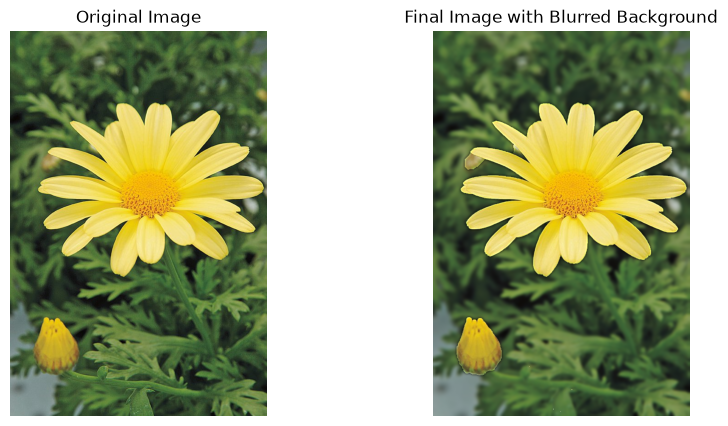

In [95]:
# apply gaussian blur to the background
blurred_background = cv.GaussianBlur(background, (15, 15), 0, 0)

# add foreground to the blurred background
final_image = cv.add(blurred_background, foreground)

# Display the final image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(flower, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(final_image, cv.COLOR_BGR2RGB))
plt.title('Final Image with Blurred Background')
plt.axis('off')

plt.show()

##### Why is the background just beyond the edge of the flower quite dark in the enhanced image?

The background right next to the flower's edge looks dark because when we blur the image, we first blacked out the flower region (set it to zero) to isolate the background, and then blurred that. Since blurring works by averaging each pixel with its neighbors, any background pixel sitting close to the flower's edge ends up averaging in some of those black zero-value pixels from the blacked-out flower area, which pulls its brightness down which creats a dark ring right along the boundary, even though that part of the real background was never actually dark.

### Smoothen the image while keeping the edges sharp.

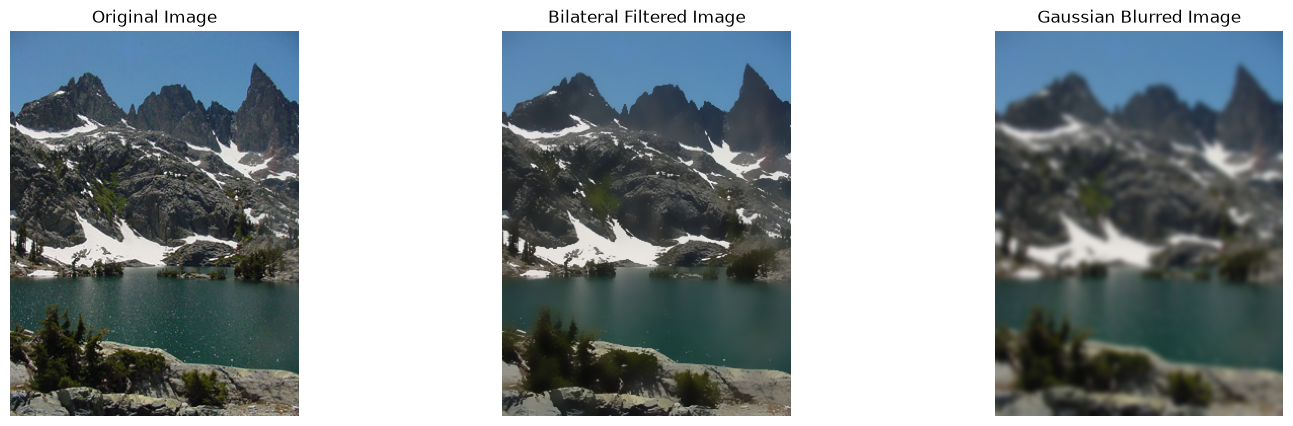

In [96]:
# load image
lake = cv.imread(r"D:\Sem 5\IP and CV\images\images\lake.jpeg", cv.IMREAD_COLOR)

# blur the image using bilateral filter
bilateral_blurred_lake = cv.bilateralFilter(lake, d=15, sigmaColor=75, sigmaSpace=75)

# gaussian blur the image
gaussian_blurred_lake = cv.GaussianBlur(lake, (15, 15), 0, 0)

# Display the images
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(lake, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(bilateral_blurred_lake, cv.COLOR_BGR2RGB))
plt.title("Bilateral Filtered Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(gaussian_blurred_lake, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

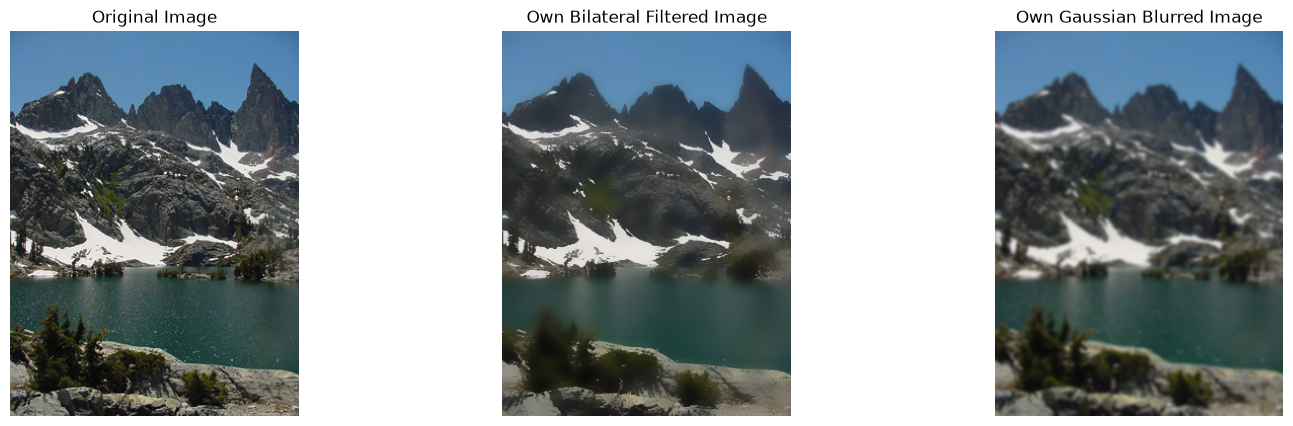

In [97]:
# bilateral filter function
def bilateral_filter(image, d, sigmaColor, sigmaSpace):
    # Convert image to float32
    image = image.astype(np.float32)

    # Get the dimensions of the image
    rows, cols, channels = image.shape

    # Create an output image
    output = np.zeros_like(image)

    # Create a Gaussian spatial kernel
    half_d = d // 2
    x, y = np.meshgrid(np.arange(-half_d, half_d + 1), np.arange(-half_d, half_d + 1))
    spatial_kernel = np.exp(-(x**2 + y**2) / (2 * sigmaSpace**2))

    # Iterate over each pixel in the image
    for i in range(rows):
        for j in range(cols):
            # Get the local region
            i_min = max(i - half_d, 0)
            i_max = min(i + half_d + 1, rows)
            j_min = max(j - half_d, 0)
            j_max = min(j + half_d + 1, cols)

            local_region = image[i_min:i_max, j_min:j_max]

            # Compute the color kernel
            color_diff = local_region - image[i, j]
            color_kernel = np.exp(-np.sum(color_diff**2, axis=2) / (2 * sigmaColor**2))

            # Combine the spatial and color kernels
            combined_kernel = spatial_kernel[(i_min - i + half_d):(i_max - i + half_d), (j_min - j + half_d):(j_max - j + half_d)] * color_kernel

            # Normalize the kernel
            combined_kernel /= np.sum(combined_kernel)

            # Apply the filter to each channel
            for c in range(channels):
                output[i, j, c] = np.sum(local_region[:, :, c] * combined_kernel)

    return output.astype(np.uint8)

# gaussian filter function
def gaussian_filter(image, kernel_size, sigma):
    # Create a Gaussian kernel
    ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)

    # Apply the Gaussian filter to each channel
    output = np.zeros_like(image)
    for c in range(image.shape[2]):
        output[:, :, c] = cv.filter2D(image[:, :, c], -1, kernel)

    return output

own_bilateral_blurred_lake = bilateral_filter(lake, d=15, sigmaColor=75, sigmaSpace=75)
own_gaussian_blurred_lake = gaussian_filter(lake, kernel_size=15, sigma=1.5)

# Display the images
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(lake, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(own_bilateral_blurred_lake, cv.COLOR_BGR2RGB))
plt.title("Own Bilateral Filtered Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(own_gaussian_blurred_lake, cv.COLOR_BGR2RGB))
plt.title("Own Gaussian Blurred Image")
plt.axis("off")

plt.show()

In [98]:
# Using PSNR to compare the results
def psnr(clean, filtered):
    mse = np.mean((clean.astype(np.float64) - filtered.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# PSNR values for bilateral filter
psnr_cv_bilateral = psnr(lake, bilateral_blurred_lake)
psnr_own_bilateral = psnr(lake, own_bilateral_blurred_lake)

def edge_preservation_index(clean, filtered):
    lap_clean = cv.Laplacian(clean, cv.CV_64F)
    lap_filtered = cv.Laplacian(filtered, cv.CV_64F)
    num = np.sum((lap_filtered - lap_filtered.mean()) * (lap_clean - lap_clean.mean()))
    den = np.sqrt(np.sum((lap_filtered - lap_filtered.mean())**2) * np.sum((lap_clean - lap_clean.mean())**2))
    return num / den

# Edge Preservation Index values for bilateral filter
epi_cv_bilateral = edge_preservation_index(lake, bilateral_blurred_lake)
epi_own_bilateral = edge_preservation_index(lake, own_bilateral_blurred_lake)

print(f"PSNR of OpenCVs bilateral filter: ", psnr_cv_bilateral)
print(f"PSNR of own bilateral filter: ", psnr_own_bilateral)
print(f"Edge Preservation Index of OpenCVs bilateral filter: ", epi_cv_bilateral)
print(f"Edge Preservation Index of own bilateral filter: ", epi_own_bilateral)

PSNR of OpenCVs bilateral filter:  29.658435450158574
PSNR of own bilateral filter:  26.219698313496615
Edge Preservation Index of OpenCVs bilateral filter:  0.8997098662947449
Edge Preservation Index of own bilateral filter:  0.832451047974465


Open CV's impementation of the bilateral filter has better performace because the PSNR and EDI values are higher in Open CV's filtered method compared to the filter I implemented.

Github link - https://github.com/Thejake22/Intensity-Transformations-and-Neighborhood-Filtering